### 4.1 (to be checked)

In [1]:
x = [1,2,3,10] 
y = [10, 20, 30, 40]

# Uses zip to add both lists
lst = [x+y for x, y in zip(x, y)] # zip() puts the every index of inputted list in to tuples
print(lst)


[11, 22, 33, 50]


In [2]:
# Using map(), replaces loop by using a function on every element in the list
x = [1,2,3,10] 
y = [10, 20, 30, 40]

def addition(e, f):
    return (e + f)

b = list(map(addition, x, y))
print(b)


[11, 22, 33, 50]


### 4.3 

In [3]:
import numpy as np

I = input(f"Please type 'R' for Rock, 'P' for paper or 'S' for Scissors:")

# Assigning numbers to input
if I == 'R':
    I = 1
elif I == 'P':
    I = 2
elif I == 'S':
    I = 3
else:
    print("Incorrect input")

# Creating random R, P, or S
C = np.random.randint(1, 3+1)  # Creates a random integer between 1 and 3 including 3

# Finding who wins
if I == C:
    print("Draw")
elif I == 1 and C == 2:
    print("Computer won")
elif I == 1 and C == 3:
    print("You won")
elif I == 2 and C == 1:
    print("Computer won")
elif I == 2 and C == 3:
    print("You won")
elif I == 3 and C == 1:
    print("Computer won")
elif I == 3 and C == 2:
    print("You won")


Please type 'R' for Rock, 'P' for paper or 'S' for Scissors: S


Computer won


### 4.4 

The standard deviation is: 7.973962515635002
The mean is: 185.0198791524571


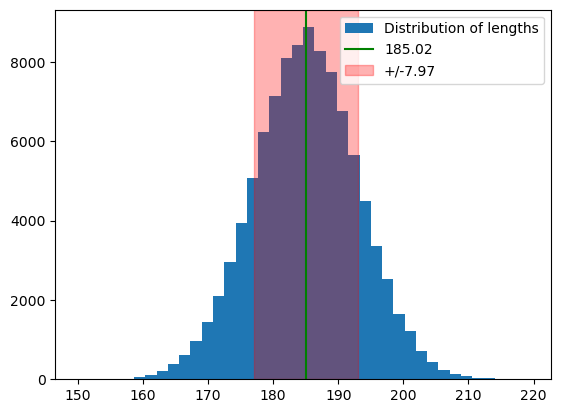

The probability is: 0.49900543472794046
The probability is: 0.6842656286920049


In [4]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

# Generating normal distribiution
lengths = np.random.normal(185, 8, 100000)  # Creates random values on a normal distribution, mean = 185, std = 8, N = 100000

# Calculating standard deviation and mean
a = np.std(lengths)
b = np.mean(lengths)
std = print(f"The standard deviation is: {a}")
mean = print(f"The mean is: {b}")

# The mean and standard deviation are close to the values I've put in

# Plotting histogram
plt.hist(lengths, bins = 40, label = "Distribution of lengths")
plt.axvline(185, color = 'green', label = f"{b:.2f}")  # Creates line at location of mean
plt.axvspan(b - a, b + a, color = 'red', alpha = 0.3, label = f"+/-{a:.2f}")  # Creates a shaded area
plt.legend()
plt.show()

# Using scipy.stats for probability of x </= h
cdf_1 = stats.norm.cdf(185, b, a)  # Probablility of a random number to be smaller than our given mean.
print(f"The probability is: {cdf_1}")

# Probability of height located within 1 std dev range
cdf_b = stats.norm.cdf(193, b, a)  # Calculates the probability of </= value, between x and y
cdf_s = stats.norm.cdf(177, b, a)
print(f"The probability is: {cdf_b - cdf_s}")

### 4.6 

In [5]:
import numpy as np
from math import *

# User can put values and functions in
function = input(f"Input a function for which you want to calculate the integral: ")
a = float(input(f"Give a lower bound: "))
b = float(input(f"Give a upper bound: "))
n = int(input(f"Give amount of random numbers: "))

# Generates random numbers uniformly        
x_random = np.random.uniform(a, b, n)  # Creates random values between the given bounds, but distributing them uniformly

# Evaluates the function for every random generated value and sums them after
p = [eval(function) for x in x_random]
sum_ = sum(p)

# Calculates the integral
integral = ((b - a) / n) * sum_
print(f"The answer of the integral is: {integral}")

Input a function for which you want to calculate the integral:  x
Give a lower bound:  1
Give a upper bound:  4
Give amount of random numbers:  10000


The answer of the integral is: 7.499853377506451


### 4.12 

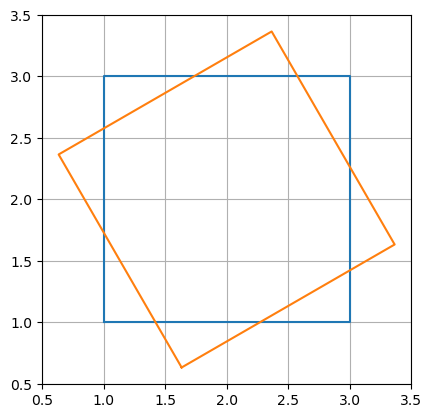

In [6]:
import math
from matplotlib import pyplot as plt
import numpy as np
lst = [x + y for x, y in zip(x, y)]

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

# Creating rotor
angle_degs = 30
theta =  math.radians(angle_degs)
rotor = math.cos(theta) + 1j*math.sin(theta)  # Is a vector

# Turning the rotor
z = x + 1j*y  # Vector existing of all points of original square
z0 = 2 + 2j  # Makes a fixed point (1,1)
zr = z0 + rotor * (z-z0) # Multiplying both vectors and keeping the square fixed at a point; makes every point of the square rotate
xr = zr.real  # Creates real component
yr = zr.imag  # Creates imaginary component

# Everything for poltting the rotor
plt.plot(x, y)  # Plots original square given by arrays
plt.plot(xr, yr)   # Plots the turned square created by multiplying the two vectors
plt.gca().set_aspect(1)  # Makes plot square
plt.grid()
plt.show()

### 4.14 (to be checked)

In [7]:
import numpy.ma as ma
import numpy as np

def funcfilter(func, seq):
    """This function filters all the values below or equal (to) zero and than uses the given function for every inputted value
    """
    arr = np.asarray(seq)
    a = arr[arr > 0] # Using np.where to filter, looking for any value under given condition, replacing them by not a number, in given array
    function = func(a)
    return function

seq = [-100, -10, 0, 10, 100]
result = funcfilter(np.log10, seq)
print("Result log10:", result)

Result log10: [1. 2.]


### 4.16 (to be checked)

In [8]:
from astropy.cosmology import Planck18
from scipy import integrate
import astropy.units as u

# Constants
H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

def t_L(z):
    """Defines the function to calculate the Cosmological lookback time"""
    Hz = H0 * (Om0 * ((1 + z)**3) + Ode0)**0.5
    y = 1/((1+z) * (Hz))
    return y

# Inputting bounds and calculating the integral to get lookback time
z = float(input(f"Input upperbound:"))
CLT, error = integrate.quad(t_L, 0 , z)
print(f"The CLT is: {CLT} and with its error: {error}")

# Convert to Gyr properly
a = CLT * 977.8

print(f"Time in Gyr: {a}")



Input upperbound: 2


The CLT is: 0.010765276277273951 and with its error: 1.7097849663277088e-15
Time in Gyr: 10.526287143918468


### 4.21

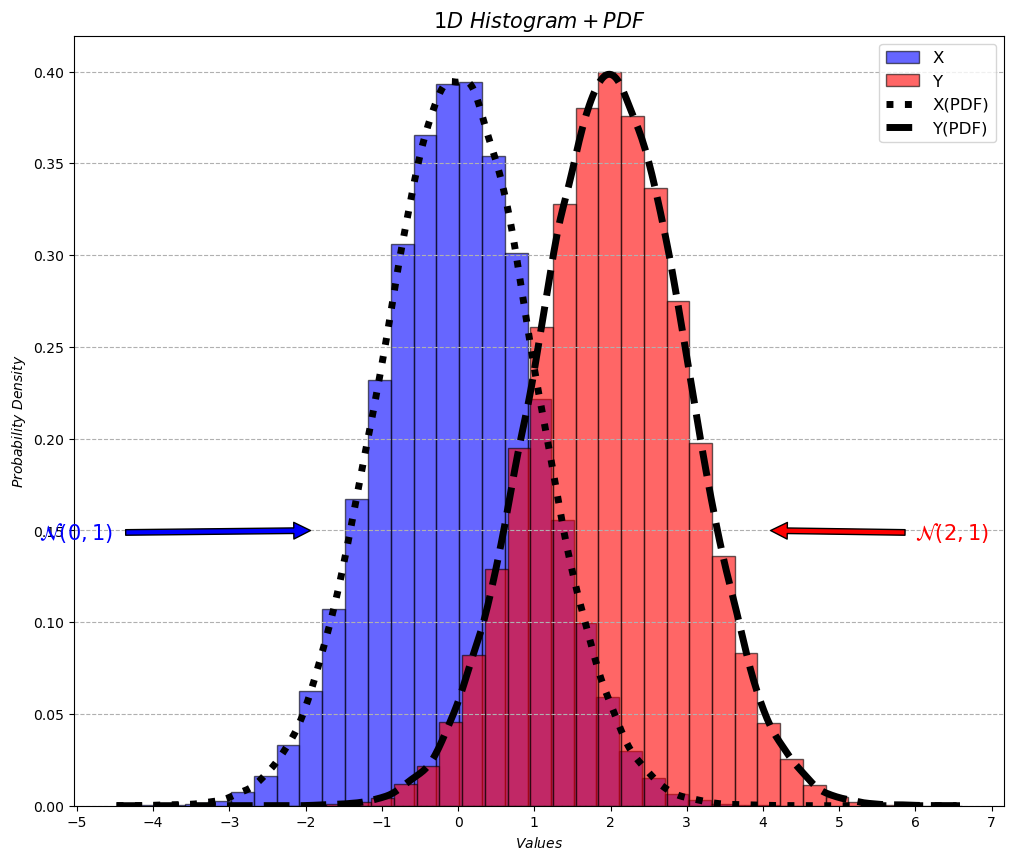

In [9]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde


# Creating the Gaussian distributions
x = np.random.normal(0, 1, 100000)
y = np.random.normal(2, 1, 100000)

# Calculating PDE of both arrays
kde_x = gaussian_kde(x)
kde_y = gaussian_kde(y)

# Calculating boundaries
xmin = min(x.min(), y.min())  # Calculates left boundary of plot
xmax = max(x.max(), y.max())  # Calculates right boundary for plot
xs = np.linspace(xmin, xmax, 500)  # Creates evenly spaced data points between bounds

# Making the plot
plt.figure(figsize = (12,10))
plt.hist(x, bins = 30, edgecolor = 'black', color = 'blue', alpha = 0.6, label = "X", density = True)
plt.hist(y, bins = 30, edgecolor = 'black', color = 'red', alpha = 0.6, label = "Y", density = True)
plt.grid(axis = 'y', linestyle = 'dashed')
plt.xticks(np.arange(-6, 8, 1))

# Plotting the density curves
plt.plot(xs, kde_x(xs), linestyle = 'dotted', linewidth=5, color = 'black', label = "X(PDF)")  # Plots the PDE for array x over the evenly spaced data points
plt.plot(xs, kde_y(xs), linewidth=5, color = 'black', linestyle = 'dashed', label = "Y(PDF)")  # Plots the PDE for array x over the evenly spaced data points

plt.annotate(r'$\mathcal{N}(0, 1)$',xy=(-1.8, 0.15), xytext=(-5.5, 0.145),
             arrowprops=dict(facecolor='blue', shrink=0.05), color='blue', fontsize=15)
plt.annotate(r'$\mathcal{N}(2,1)$',xy=(4, 0.15), xytext=(6, 0.145),
             arrowprops=dict(facecolor='r', shrink=0.05), color='r', fontsize=15)

# Annotations around plot
plt.title(label = r'$1D \ Histogram + PDF$', size = 15)
plt.legend(fontsize = 12)
plt.xlabel(r'$Values$')
plt.ylabel(r'$Probability \ Density$')
plt.show()



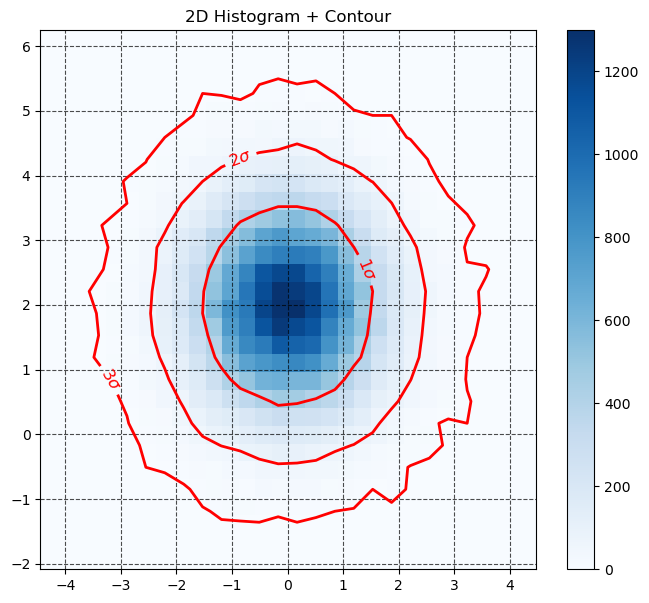

In [10]:
#2D Histogram

X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

bins = 30
range_lim = [[-17, 17],[-17,17]]

H, xedges, yedges = np.histogram2d(X, Y, bins=100, range = range_lim)

# Bin centers (needed for contour)
xcenters = (xedges[:-1] + xedges[1:]) / 2
ycenters = (yedges[:-1] + yedges[1:]) / 2

# Meshgrid for contour
Xgrid, Ygrid = np.meshgrid(xcenters, ycenters)

# 1. Flatten and sort the histogram values in descending order
H_flat = H.flatten()
H_sort = np.sort(H_flat)[::-1]

# 2. Calculate the cumulative sum of the sorted bins
cumulative_sum = np.cumsum(H_sort)
cumulative_prob = cumulative_sum / cumulative_sum[-1]

target_probs = [0.68, 0.95, 0.997]
levels = []

for p in target_probs:
    # Find the threshold bin value
    idx = np.where(cumulative_prob >= p)[0][0]
    levels.append(H_sort[idx])

levels = sorted(levels)

plt.figure(figsize=(8, 7))
plt.hist2d(X,Y, bins = bins, cmap = "Blues")
plt.colorbar(label='')
plt.grid(True, linestyle='--', color='black', alpha=0.7)


contours = plt.contour(
    Xgrid, Ygrid, H.T,
    levels=levels,
    colors="red",
    linewidths=2
)

fmt = {
    levels[2]: r'$1\sigma$',
    levels[1]: r'$2\sigma$',
    levels[0]: r'$3\sigma$'
}

plt.clabel(contours, contours.levels, inline=True, fmt=fmt, fontsize=12, colors='red')

plt.title(f"2D Histogram + Contour")


plt.show()